<a href="https://colab.research.google.com/github/beyza-ozdemir/Amazon_Price_Tracker/blob/main/Pycharm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# 1. Pandas'ı içe aktar
import pandas as pd


# 2. CSV dosyasını oku
df_data = pd.read_csv(
    '/content/drive/MyDrive/LEGO+Notebook+and+Data+(start)/mission_launches.csv'
)

df_data.head()


# 4. Veri setinin boyutuna bak
# (satır sayısı, sütun sayısı)
df_data.shape

# 5. Sütun isimlerini gör
df_data.columns

# 6. Veri tiplerini ve dolu değer sayılarını gör
df_data.info()

# 7. Her sütundaki eksik değer sayısını bul
df_data.isnull().sum()


# 8. Tekrar eden satır sayısını bul
df_data.duplicated().sum()

df_data["Price"].head()

df_data["Price"]=pd.to_numeric(df_data["Price"],errors="coerce")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [ ]:


df_data["Date"] = pd.to_datetime(
    df_data["Date"],
    format="mixed",
    utc=True
)
df_data["Year"] = df_data["Date"].dt.year

In [ ]:
df_data = df_data.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])

In [ ]:
df_data.shape
df_data.columns
df_data["Year"].value_counts().sort_index()

df_data.columns

Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status', 'Year'],
      dtype='object')

Hangi kuruluş en çok fırlatma yapmış ?

In [ ]:
df_data["Organisation"].value_counts().head(1)
launches_by_year_org=df_data.groupby(["Year", "Organisation"]).size()
idx=launches_by_year_org.groupby(level=0).idxmax()
print(launches_by_year_org.loc[idx])



Year  Organisation
1957  RVSN USSR        2
1958  US Navy         12
1959  US Air Force    10
1960  US Air Force    21
1961  US Air Force    23
                      ..
2016  CASC            22
2017  SpaceX          18
2018  CASC            37
2019  CASC            27
2020  CASC            19
Length: 64, dtype: int64


Uzay görevlerinin maliyeti yıllar içinde nasıl değişmiş?

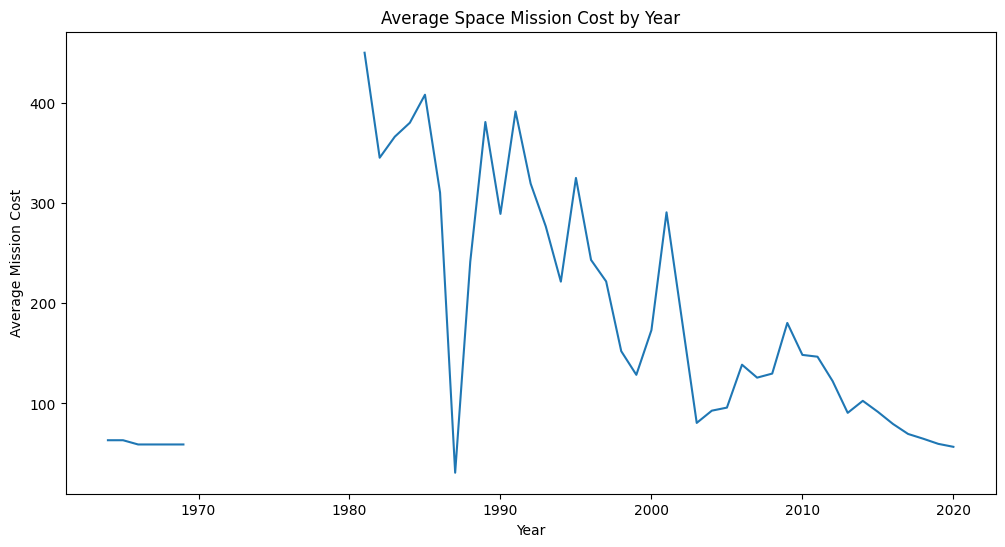

In [ ]:
import matplotlib.pyplot as plt

df_data["Price"].head()
avg_price_by_year=df_data.groupby("Year")["Price"].mean()
plt.figure(figsize=(12, 6))
plt.plot(avg_price_by_year.index, avg_price_by_year.values)
plt.title("Average Space Mission Cost by Year")
plt.xlabel("Year")
plt.ylabel("Average Mission Cost")
plt.show()

Hangi aylarda daha fazla fırlatma yapılmış?

In [ ]:
import calendar


df_data["Month"] = df_data["Date"].dt.month
launches_by_month = df_data["Month"].value_counts().sort_index()
most_popular_month=launches_by_month.idxmax()

calendar.month_name[most_popular_month]

'December'

Uzay görevleri zamanla daha güvenli hale gelmiş mi?

Text(0, 0.5, 'Success Rate (%)')

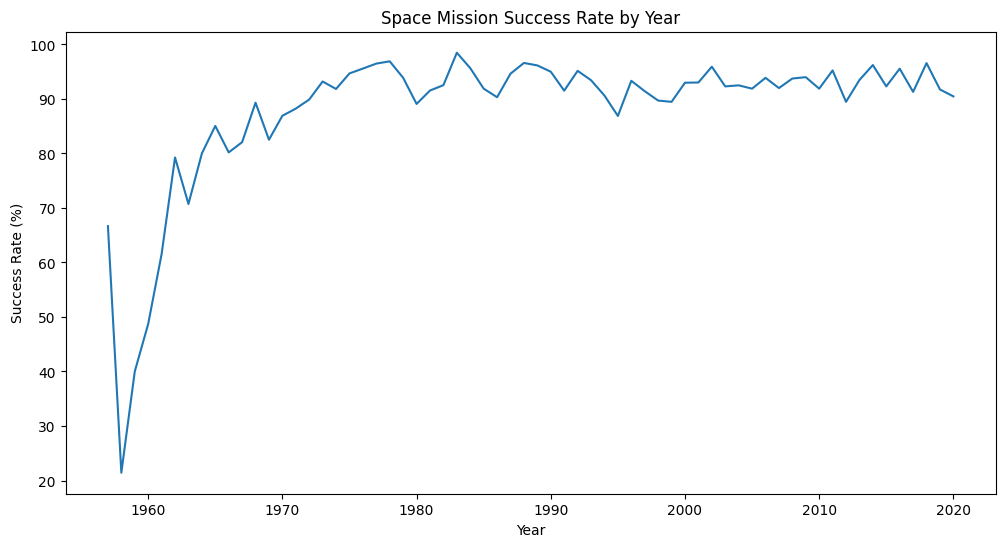

In [ ]:
import matplotlib.pyplot as plt

df_data["Mission_Status"].value_counts()
df_data.groupby(["Year", "Mission_Status"]).size()
successful_missions = df_data[df_data["Mission_Status"] == "Success"]
total_missions_by_year = df_data.groupby("Year").size()
successful_by_year = successful_missions.groupby("Year").size()
success_rate = successful_by_year / total_missions_by_year * 100

plt.figure(figsize=(12, 6))
plt.plot(success_rate.index, success_rate.values)
plt.title("Space Mission Success Rate by Year")
plt.xlabel("Year")
plt.ylabel("Success Rate (%)")
plt.show()

<BarContainer object of 12 artists>

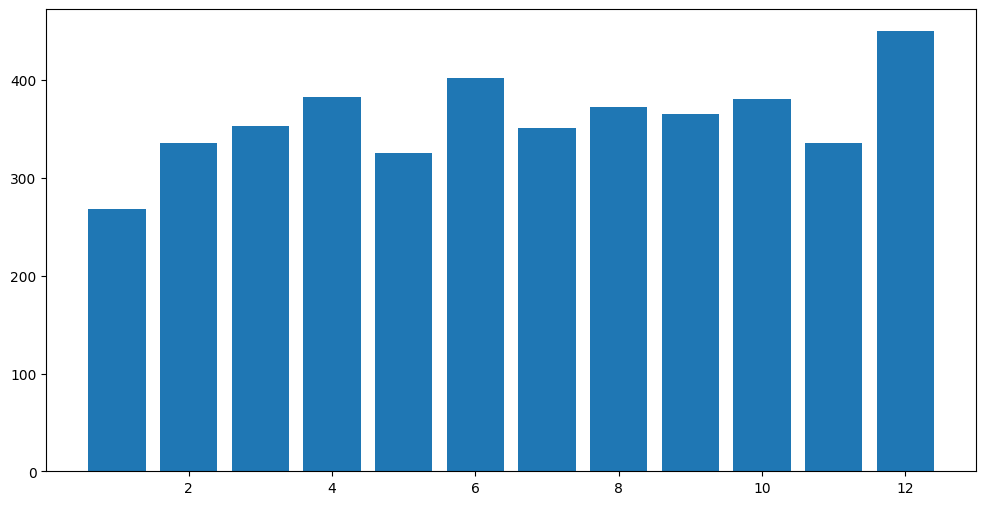

In [ ]:
import matplotlib.pyplot as plt

df_data["Month"]=df_data['Date'].dt.month
df_data["Month"].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(df_data["Month"].value_counts().index, df_data["Month"].value_counts().values)

In [ ]:
top_organisations = df_data["Organisation"].value_counts().head(10)
df_data["Organisation"].value_counts()
plt.figure(figsize=(12, 6))
plt.bar(top_organisations.index, top_organisations.values)
plt.xlabel("Organisation")
plt.ylabel("Number of Launches")
plt.title("Top 10 Organisations by Number of Launches")
plt.xticks(rotation=45)
plt.show()

Bunu çizdikten